# 📊 Clase 6 — Muestra y muestreo
## Fundamentos del método científico y probabilidad

**Desafío inicial:** Una empresa de telecomunicaciones debe evaluar la satisfacción de 600.000 clientes con solo 3.000 encuestas posibles. El equipo debe construir una muestra representativa considerando zona geográfica, tipo de plan y canal de atención. Una mala elección lleva a conclusiones erróneas.

**Objetivos:**
- Distinguir **población, muestra y muestreo**
- Implementar **muestreo aleatorio simple** con pandas `.sample()`
- Detectar y cuantificar el **sesgo de muestra**
- Aplicar **muestreo estratificado, por conglomerados y de varias etapas**
- Diseñar una estrategia de muestreo para un caso real

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## PARTE 1 — Conceptos clave: población, muestra y muestreo

### 1.1 Tabla comparativa — slide 7

In [2]:
tabla_conceptos = pd.DataFrame({
    'Concepto': ['Población','Muestra','Muestreo'],
    'Definición': [
        'Conjunto total de elementos a estudiar.',
        'Subconjunto representativo extraído de la población.',
        'Método para seleccionar la muestra.'
    ],
    'Ejemplo en ciencia de datos': [
        'Todos los usuarios registrados en una plataforma',
        '10.000 usuarios seleccionados aleatoriamente',
        'Muestreo aleatorio simple, estratificado, por clusters'
    ]
})
print('=== Población, Muestra y Muestreo (slide 7) ===')
print(tabla_conceptos.to_string(index=False))

=== Población, Muestra y Muestreo (slide 7) ===
 Concepto                                           Definición                            Ejemplo en ciencia de datos
Población              Conjunto total de elementos a estudiar.       Todos los usuarios registrados en una plataforma
  Muestra Subconjunto representativo extraído de la población.           10.000 usuarios seleccionados aleatoriamente
 Muestreo                  Método para seleccionar la muestra. Muestreo aleatorio simple, estratificado, por clusters


### 1.2 Implementación en Python — código exacto slide 8

In [3]:
# Código exacto de la presentación — slide 8
import pandas as pd

# Simulamos una población de 100,000 registros
poblacion = pd.DataFrame({"cliente_id": range(1, 100001)})

# Tomamos una muestra aleatoria del 1%
muestra = poblacion.sample(frac=0.01, random_state=42)
print(muestra.head())

       cliente_id
75721       75722
80184       80185
19864       19865
76699       76700
92991       92992


In [4]:
print(f'Tamaño de la población: {len(poblacion):,}')
print(f'Tamaño de la muestra (1%): {len(muestra):,}')
print(f'Fracción real: {len(muestra)/len(poblacion)*100:.1f}%')

Tamaño de la población: 100,000
Tamaño de la muestra (1%): 1,000
Fracción real: 1.0%


---
## PARTE 2 — Sesgo de muestra

### 2.1 ¿Qué es el sesgo y cómo se origina? — slides 10-12

In [5]:
tabla_sesgo = pd.DataFrame({
    'Causa de sesgo': [
        'Muestreo por conveniencia',
        'Ausencia de aleatorización',
        'Mala definición del marco muestral',
        'Auto-selección de participantes'
    ],
    'Descripción': [
        'Seleccionar lo que está más a mano',
        'No garantizar igualdad de probabilidad de selección',
        'El marco excluye subgrupos importantes',
        'Los participantes se incluyen voluntariamente (perfil sesgado)'
    ],
    'Ejemplo en datos': [
        'Encuestar solo en un horario específico',
        'Tomar siempre los primeros N registros',
        'Incluir solo clientes con email registrado',
        'Encuesta voluntaria en app (solo usuarios activos responden)'
    ]
})
print('=== Causas del sesgo de muestra (slide 12) ===')
print(tabla_sesgo.to_string(index=False))

=== Causas del sesgo de muestra (slide 12) ===
                    Causa de sesgo                                                    Descripción                                             Ejemplo en datos
         Muestreo por conveniencia                             Seleccionar lo que está más a mano                      Encuestar solo en un horario específico
        Ausencia de aleatorización            No garantizar igualdad de probabilidad de selección                       Tomar siempre los primeros N registros
Mala definición del marco muestral                         El marco excluye subgrupos importantes                   Incluir solo clientes con email registrado
   Auto-selección de participantes Los participantes se incluyen voluntariamente (perfil sesgado) Encuesta voluntaria en app (solo usuarios activos responden)


Población total: 100,000 clientes



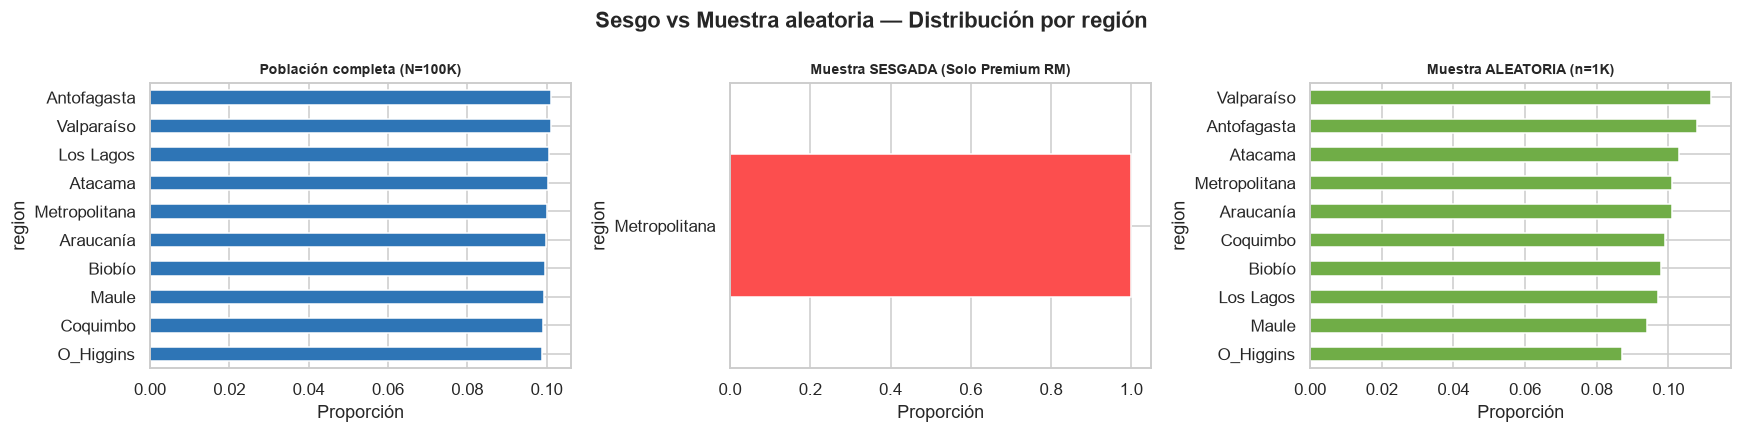

La muestra sesgada solo contiene una región, distorsionando cualquier análisis geográfico.


In [7]:
# Demostración cuantitativa de sesgo vs muestra aleatoria
clientes = pd.read_csv('06. Apoyo ejercicio - Clientes.csv')
print(f'Población total: {len(clientes):,} clientes')
print()

# Distribución real de la población
dist_real = clientes['region'].value_counts(normalize=True).round(4)

# Muestra SESGADA: solo clientes con plan Premium de la RM
muestra_sesgada = clientes[
    (clientes['plan']=='Premium') & (clientes['region']=='Metropolitana')
].sample(n=1000, random_state=42)

# Muestra ALEATORIA: 1000 registros al azar
muestra_aleatoria = clientes.sample(n=1000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Sesgo vs Muestra aleatoria — Distribución por región', fontweight='bold')

for ax, datos, titulo, color in zip(
    axes,
    [clientes, muestra_sesgada, muestra_aleatoria],
    ['Población completa (N=100K)','Muestra SESGADA (Solo Premium RM)','Muestra ALEATORIA (n=1K)'],
    ['#2E75B6','#FC4E4E','#70AD47']
):
    dist = datos['region'].value_counts(normalize=True).sort_values(ascending=True)
    dist.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(titulo, fontsize=9, fontweight='bold')
    ax.set_xlabel('Proporción')

plt.tight_layout()
plt.show()

print('La muestra sesgada solo contiene una región, distorsionando cualquier análisis geográfico.')

---
## PARTE 3 — Los 4 métodos de muestreo

### 3.1 Muestreo aleatorio simple — código exacto slide 18

In [9]:
# Código exacto de la presentación — slide 18
import pandas as pd

clientes = pd.read_csv('06. Apoyo ejercicio - Clientes.csv')
muestra_simple = clientes.sample(n=1000, random_state=1)
print(muestra_simple.head())

       cliente_id       region      plan canal_atencion tipo_cliente  \
43660       43661    Araucanía    Básico            App  Residencial   
87278       87279      Atacama    Básico            Web  Empresarial   
14317       14318       Biobío   Premium       Sucursal  Residencial   
81932       81933     Coquimbo  Estándar       Sucursal  Residencial   
95321       95322  Antofagasta  Estándar            App  Residencial   

       satisfaccion  meses_activo  
43660           8.0            49  
87278           8.6            46  
14317           6.4            78  
81932           9.3            74  
95321           4.6            52  


In [10]:
# Verificar representatividad de la muestra simple
print('=== Comparación: Población vs Muestra Simple (n=1000) ===')
for col in ['region','plan','tipo_cliente']:
    pob_dist = clientes[col].value_counts(normalize=True).round(3)
    mue_dist = muestra_simple[col].value_counts(normalize=True).round(3)
    comp = pd.DataFrame({'Población':pob_dist,'Muestra simple':mue_dist}).fillna(0)
    comp['Diferencia'] = (comp['Muestra simple'] - comp['Población']).round(3)
    print(f'\n{col}:')
    print(comp.to_string())

=== Comparación: Población vs Muestra Simple (n=1000) ===

region:
               Población  Muestra simple  Diferencia
region                                              
Antofagasta        0.101           0.116       0.015
Araucanía          0.100           0.107       0.007
Atacama            0.100           0.088      -0.012
Biobío             0.100           0.104       0.004
Coquimbo           0.099           0.094      -0.005
Los Lagos          0.101           0.100      -0.001
Maule              0.099           0.094      -0.005
Metropolitana      0.100           0.102       0.002
O_Higgins          0.099           0.097      -0.002
Valparaíso         0.101           0.098      -0.003

plan:
             Población  Muestra simple  Diferencia
plan                                              
Básico           0.400           0.378      -0.022
Estándar         0.301           0.327       0.026
Premium          0.199           0.199       0.000
Empresarial      0.100           0.

### 3.2 Muestreo aleatorio estratificado — slide 19

In [17]:
# Muestreo estratificado proporcional por 'plan'
n_muestra_estrat = 1000

fraccion = n_muestra_estrat / len(clientes)
muestra_estrat = clientes.groupby('plan', group_keys=False).sample(
    frac=fraccion,
    random_state=42
)


print(f'Muestra estratificada: {len(muestra_estrat)} registros')
print()

print('=== Distribución por plan: Población vs Estratificado ===')
comp_estrat = pd.DataFrame({
    'Población': clientes['plan'].value_counts(normalize=True).round(4),
    'Estratificado': muestra_estrat['plan'].value_counts(normalize=True).round(4)
})
comp_estrat['Diferencia'] = (comp_estrat['Estratificado'] - comp_estrat['Población']).round(4)
print(comp_estrat)

Muestra estratificada: 1000 registros

=== Distribución por plan: Población vs Estratificado ===
             Población  Estratificado  Diferencia
plan                                             
Básico          0.3997          0.400      0.0003
Estándar        0.3014          0.301     -0.0004
Premium         0.1994          0.199     -0.0004
Empresarial     0.0995          0.100      0.0005


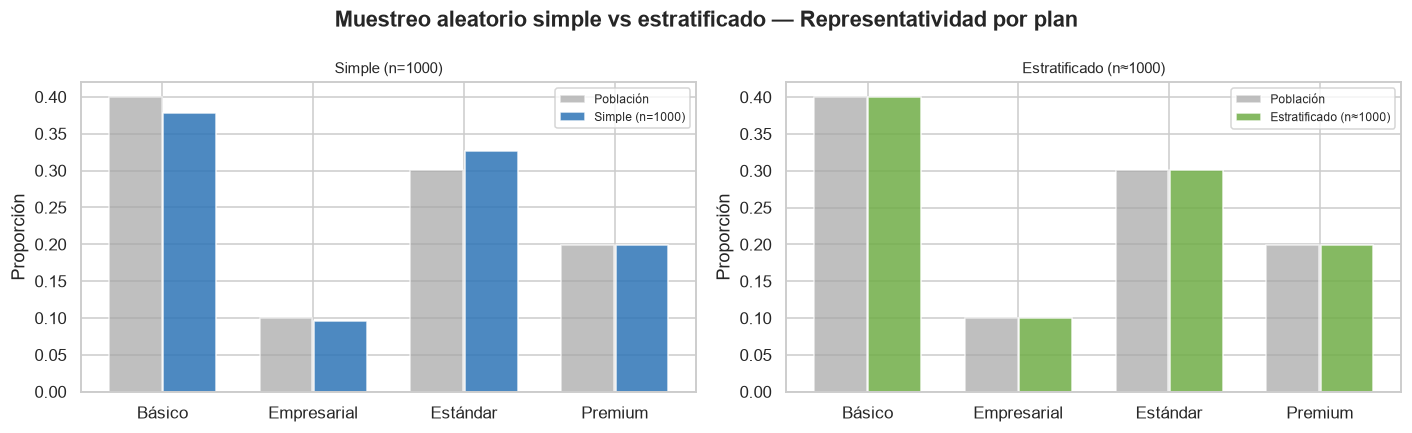

In [18]:
# Visualizar ventaja del estratificado vs simple
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Muestreo aleatorio simple vs estratificado — Representatividad por plan',
             fontweight='bold')

for ax, muestra, titulo, color in zip(
    axes,
    [muestra_simple, muestra_estrat],
    ['Simple (n=1000)','Estratificado (n≈1000)'],
    ['#2E75B6','#70AD47']
):
    pob  = clientes['plan'].value_counts(normalize=True).sort_index()
    mue  = muestra['plan'].value_counts(normalize=True).sort_index()
    x = np.arange(len(pob))
    ax.bar(x-0.18, pob.values, width=0.35, label='Población', color='#A5A5A5', alpha=0.7)
    ax.bar(x+0.18, mue.reindex(pob.index).fillna(0).values,
           width=0.35, label=titulo, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(pob.index)
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel('Proporción')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.3 Muestreo por conglomerados — slide 21

In [19]:
# Muestreo por conglomerados: regiones como clusters
np.random.seed(42)
n_clusters = 4
regiones_totales = clientes['region'].unique()
clusters_seleccionados = np.random.choice(regiones_totales, size=n_clusters, replace=False)

muestra_clusters = clientes[clientes['region'].isin(clusters_seleccionados)]

print(f'Conglomerados (regiones) seleccionados: {clusters_seleccionados}')
print(f'N en muestra por conglomerados: {len(muestra_clusters):,}')
print()
print('=== Distribución de regiones en la muestra por clusters ===')
print(muestra_clusters['region'].value_counts())

Conglomerados (regiones) seleccionados: ['O_Higgins' 'Araucanía' 'Maule' 'Valparaíso']
N en muestra por conglomerados: 39,908

=== Distribución de regiones en la muestra por clusters ===
region
Valparaíso    10099
Araucanía      9986
Maule          9932
O_Higgins      9891
Name: count, dtype: int64


### 3.4 Muestreo de varias etapas — slide 23

In [20]:
# Muestreo de varias etapas:
# Etapa 1: seleccionar 4 regiones (conglomerados)
# Etapa 2: dentro de cada región, muestra aleatoria simple de 250

np.random.seed(42)
regiones_e1 = np.random.choice(clientes['region'].unique(), size=4, replace=False)

muestra_etapas = []
for region in regiones_e1:
    sub = clientes[clientes['region'] == region]
    n_e2 = min(250, len(sub))
    muestra_etapas.append(sub.sample(n=n_e2, random_state=42))

muestra_varias_etapas = pd.concat(muestra_etapas)

print('=== Muestreo de varias etapas ===')
print(f'Etapa 1: {len(regiones_e1)} regiones seleccionadas: {regiones_e1}')
print(f'Etapa 2: 250 clientes por región')
print(f'N total: {len(muestra_varias_etapas)}')
print()
print(muestra_varias_etapas.groupby('region').size().to_frame('n'))

=== Muestreo de varias etapas ===
Etapa 1: 4 regiones seleccionadas: ['O_Higgins' 'Araucanía' 'Maule' 'Valparaíso']
Etapa 2: 250 clientes por región
N total: 1000

              n
region         
Araucanía   250
Maule       250
O_Higgins   250
Valparaíso  250


### 3.5 Tabla comparativa — slide 25

In [21]:
tabla_comp = pd.DataFrame({
    'Tipo de muestreo': [
        'Aleatorio simple',
        'Aleatorio estratificado',
        'Por conglomerados',
        'De varias etapas'
    ],
    'Cuándo se recomienda': [
        'Población homogénea, acceso completo al marco',
        'Población heterogénea con subgrupos conocidos',
        'Población dispersa o costosa de cubrir individualmente',
        'Población jerárquica o muy extensa'
    ],
    'Ventajas principales': [
        'Fácil de aplicar, resultados generalizables',
        'Mayor precisión, permite comparaciones válidas',
        'Menor costo, operativo más simple',
        'Flexible, adaptable, balance precisión-costo'
    ],
    'Riesgos o desventajas': [
        'Riesgo de exclusión de subgrupos relevantes',
        'Requiere clasificación previa, más complejo',
        'Menor precisión si hay heterogeneidad interna',
        'Mayor complejidad, riesgo de error acumulado'
    ]
})
print('=== Tabla comparativa de métodos de muestreo (slide 25) ===')
print(tabla_comp.to_string(index=False))

=== Tabla comparativa de métodos de muestreo (slide 25) ===
       Tipo de muestreo                                   Cuándo se recomienda                           Ventajas principales                         Riesgos o desventajas
       Aleatorio simple          Población homogénea, acceso completo al marco    Fácil de aplicar, resultados generalizables   Riesgo de exclusión de subgrupos relevantes
Aleatorio estratificado          Población heterogénea con subgrupos conocidos Mayor precisión, permite comparaciones válidas   Requiere clasificación previa, más complejo
      Por conglomerados Población dispersa o costosa de cubrir individualmente              Menor costo, operativo más simple Menor precisión si hay heterogeneidad interna
       De varias etapas                     Población jerárquica o muy extensa   Flexible, adaptable, balance precisión-costo  Mayor complejidad, riesgo de error acumulado


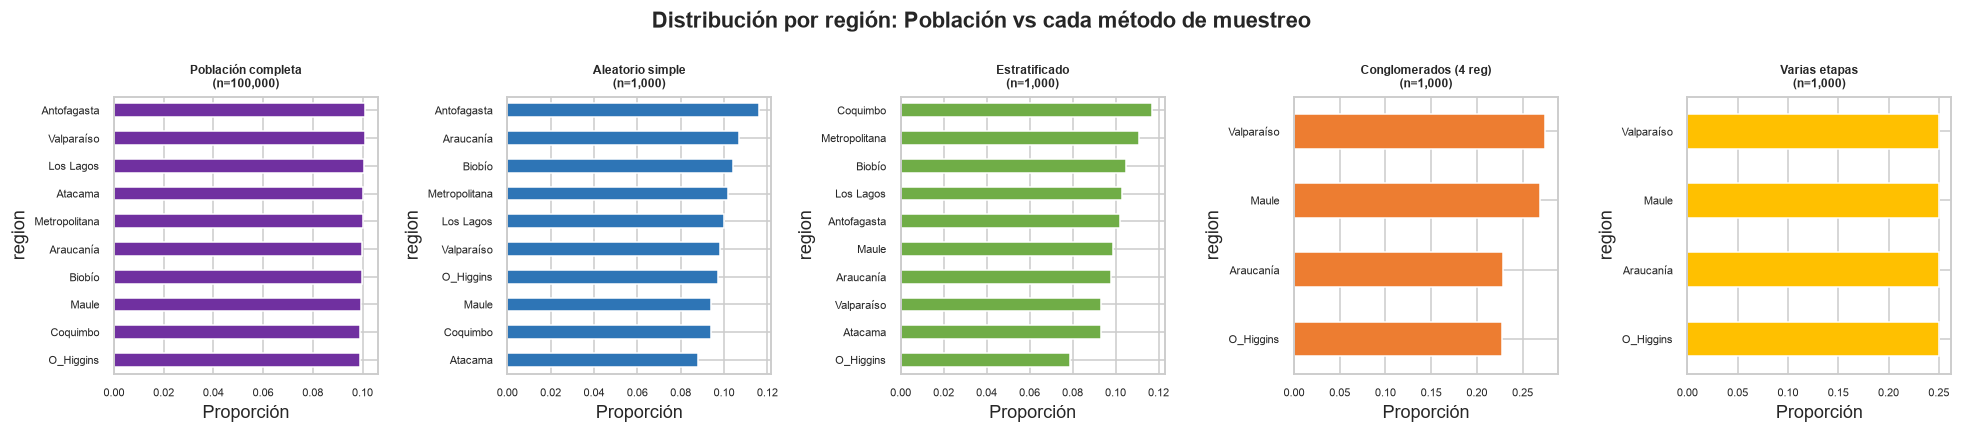

In [22]:
# Resumen visual: tamaño y representatividad de cada método
metodos = {
    'Población completa':    clientes,
    'Aleatorio simple':      muestra_simple,
    'Estratificado':         muestra_estrat,
    'Conglomerados (4 reg)': muestra_clusters.sample(n=min(1000,len(muestra_clusters)), random_state=42),
    'Varias etapas':         muestra_varias_etapas,
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Distribución por región: Población vs cada método de muestreo',
             fontweight='bold')
colores = ['#7030A0','#2E75B6','#70AD47','#ED7D31','#FFC000']

for ax, (nombre, datos), color in zip(axes, metodos.items(), colores):
    dist = datos['region'].value_counts(normalize=True).sort_values(ascending=True)
    dist.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{nombre}\n(n={len(datos):,})', fontsize=8, fontweight='bold')
    ax.set_xlabel('Proporción')
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

### ✏️ Ejercicio — Reflexiona (preguntas cierre 1-4):

In [23]:
# ✏️ Cierre 1: ¿Qué condiciones debe cumplir una muestra representativa?
c1 = ""

# ✏️ Cierre 2: ¿Cuándo preferir estratificado sobre simple?
c2 = ""

# ✏️ Cierre 3: ¿Ventaja del muestreo por conglomerados vs aleatorio simple?
c3 = ""

# ✏️ Cierre 4: ¿Qué es el sesgo y cómo afecta a un modelo predictivo?
c4 = ""

print(f'1. {c1}')
print(f'2. {c2}')
print(f'3. {c3}')
print(f'4. {c4}')

1. 
2. 
3. 
4. 


---
## PARTE 4 — Actividad guiada: Institución educativa técnica (slides 27-29)

### 4.1 Cargar y explorar el marco muestral

In [25]:
df_edu = pd.read_csv('06. Apoyo ejercicio - Marco muestral.csv')
print(f'Población total: {len(df_edu):,} estudiantes')
print()
print(df_edu.head(8))
print()
print('=== Distribución de variables clave ===')
for col in ['region','modalidad','jornada']:
    print(f'\n{col}:')
    print(df_edu[col].value_counts())

Población total: 65,121 estudiantes

  id_estudiante   sede         region    modalidad     jornada  \
0     EST000001  MET01  Metropolitana   Presencial  Vespertino   
1     EST000002  MET01  Metropolitana   Presencial      Diurno   
2     EST000003  MET01  Metropolitana   Presencial      Diurno   
3     EST000004  MET01  Metropolitana   Presencial      Diurno   
4     EST000005  MET01  Metropolitana  A distancia      Diurno   
5     EST000006  MET01  Metropolitana  A distancia  Vespertino   
6     EST000007  MET01  Metropolitana  A distancia      Diurno   
7     EST000008  MET01  Metropolitana   Presencial      Diurno   

              programa  anio_cursado  
0    Marketing Digital             1  
1         Contabilidad             3  
2           Enfermería             2  
3          Gastronomía             3  
4         Electricidad             4  
5           Enfermería             2  
6  Mecánica Automotriz             2  
7       Diseño Gráfico             3  

=== Distribución

In [26]:
print('=== Sedes por región ===')
print(df_edu.groupby('region')['sede'].nunique().sort_values(ascending=False))
print()
print(f'N° sedes totales: {df_edu["sede"].nunique()}')
print(f'N° regiones: {df_edu["region"].nunique()}')

=== Sedes por región ===
region
Metropolitana    8
Biobío           5
Valparaíso       4
Araucanía        3
Maule            3
Los Lagos        3
O_Higgins        3
Antofagasta      2
Coquimbo         2
Atacama          2
Name: sede, dtype: int64

N° sedes totales: 35
N° regiones: 10


### 4.2 Análisis de la población (identificar variables a representar)

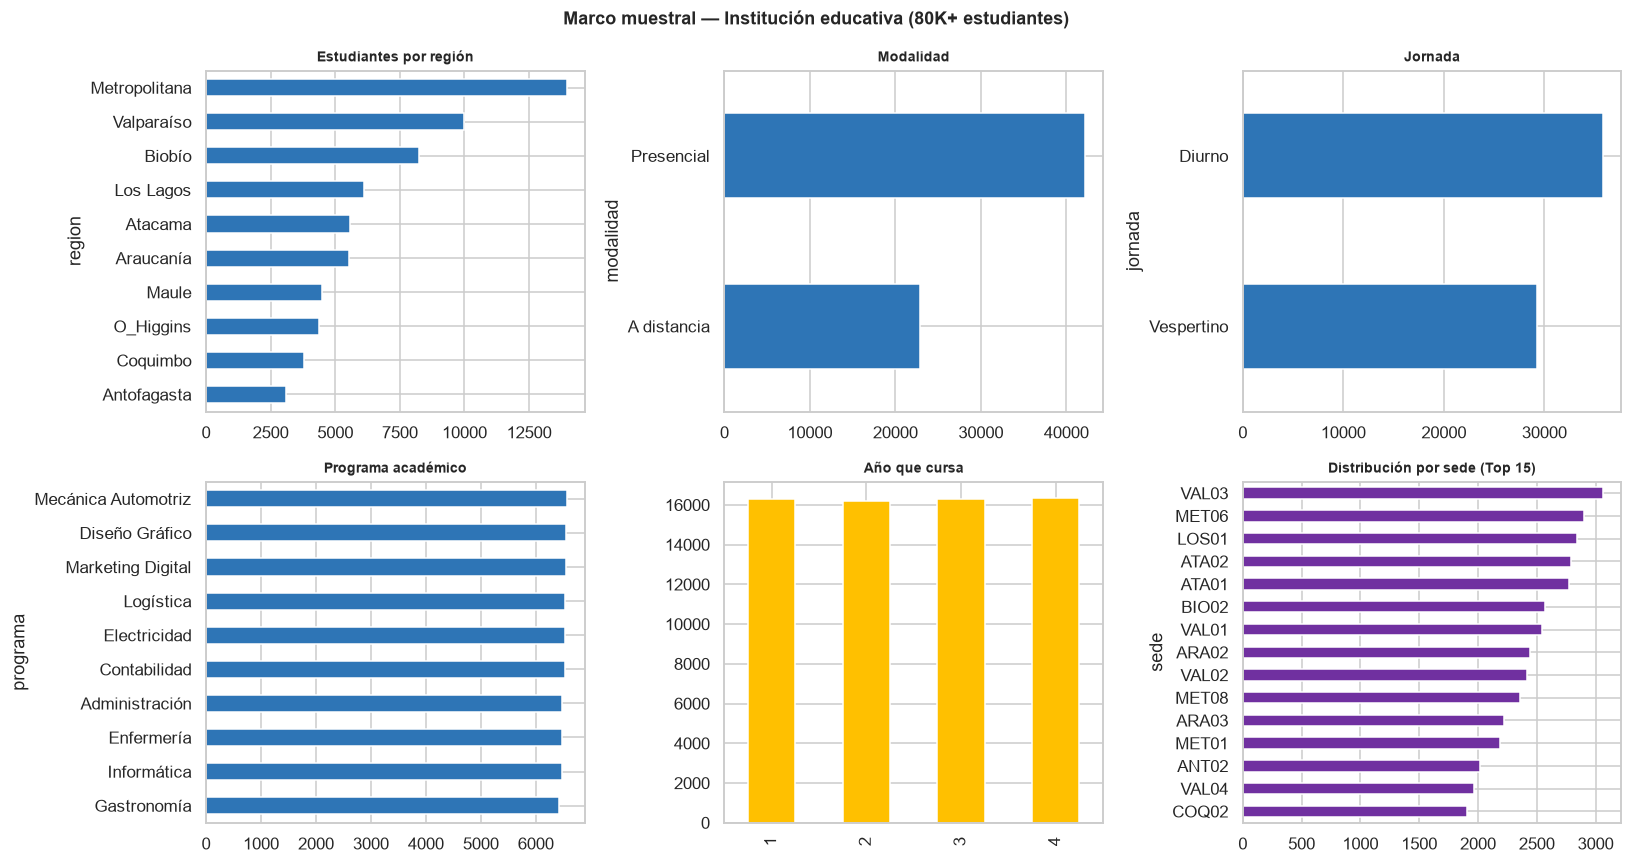

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Marco muestral — Institución educativa (80K+ estudiantes)',
             fontweight='bold', fontsize=12)

vars_plot = [
    ('region',    'Estudiantes por región'),
    ('modalidad', 'Modalidad'),
    ('jornada',   'Jornada'),
    ('programa',  'Programa académico'),
    ('anio_cursado','Año que cursa'),
    ('sede',      'Distribución por sede (Top 15)'),
]

for ax, (col, titulo) in zip(axes.flat, vars_plot):
    if col == 'sede':
        top = df_edu[col].value_counts().head(15)
        top.sort_values().plot(kind='barh', ax=ax, color='#7030A0', edgecolor='white')
    elif col in ['anio_cursado']:
        df_edu[col].value_counts().sort_index().plot(kind='bar', ax=ax,
                                                      color='#FFC000', edgecolor='white')
    else:
        df_edu[col].value_counts().sort_values(ascending=True).plot(
            kind='barh', ax=ax, color='#2E75B6', edgecolor='white')
    ax.set_title(titulo, fontsize=9, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 4.3 Diseñar la estrategia de muestreo (instrucciones slides 28-29)

In [28]:
# Objetivo: obtener n=3000 estudiantes representativos
# Método recomendado: muestreo de varias etapas
# Etapa 1: seleccionar sedes por región (conglomerado)
# Etapa 2: dentro de cada sede, muestra estratificada por modalidad y jornada

n_objetivo = 3000
n_total = len(df_edu)
fraccion = n_objetivo / n_total

print(f'Población: {n_total:,} | Objetivo: {n_objetivo:,} | Fracción: {fraccion:.4f}')
print()

# Muestra estratificada por región + modalidad (estrato = región × modalidad)
df_edu['estrato'] = df_edu['region'] + '_' + df_edu['modalidad']
n_estratos = df_edu['estrato'].nunique()

muestra_edu = (
    df_edu
    .groupby('estrato', group_keys=False)
    .apply(lambda x: x.sample(
        n=max(1, round(n_objetivo * len(x) / n_total)),
        random_state=42
    ))
)

print(f'N° estratos (región × modalidad): {n_estratos}')
print(f'Muestra obtenida: {len(muestra_edu):,}')
print()
print('=== Distribución de la muestra por estrato ===')
print(muestra_edu.groupby(['region','modalidad']).size().to_frame('n_muestra').head(10))

Población: 65,121 | Objetivo: 3,000 | Fracción: 0.0461

N° estratos (región × modalidad): 20
Muestra obtenida: 3,001

=== Distribución de la muestra por estrato ===
                         n_muestra
region      modalidad             
Antofagasta A distancia         48
            Presencial          94
Araucanía   A distancia         90
            Presencial         165
Atacama     A distancia         90
            Presencial         167
Biobío      A distancia        133
            Presencial         247
Coquimbo    A distancia         60
            Presencial         115


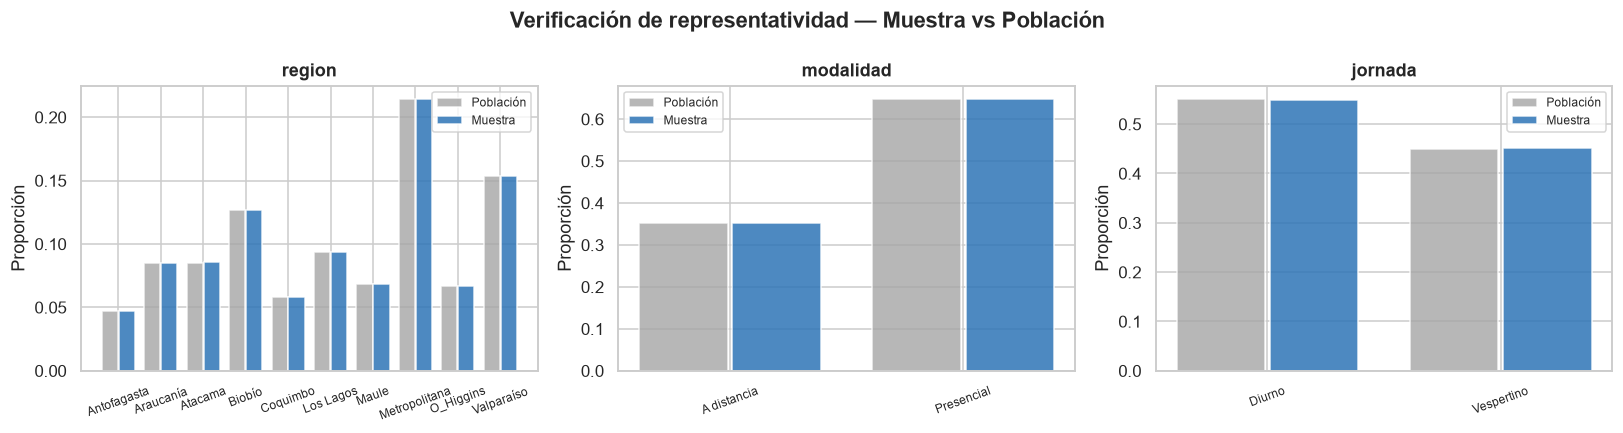

In [29]:
# Verificar representatividad
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Verificación de representatividad — Muestra vs Población',
             fontweight='bold')

for ax, col in zip(axes, ['region','modalidad','jornada']):
    pob_d = df_edu[col].value_counts(normalize=True).sort_index()
    mue_d = muestra_edu[col].value_counts(normalize=True).sort_index()
    x = np.arange(len(pob_d))
    ax.bar(x-0.2, pob_d.values, width=0.38, label='Población', color='#A5A5A5', alpha=0.8)
    ax.bar(x+0.2, mue_d.reindex(pob_d.index).fillna(0).values,
           width=0.38, label='Muestra', color='#2E75B6', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(pob_d.index, rotation=20, fontsize=8)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Proporción')

plt.tight_layout()
plt.show()

### 4.4 Plantilla de planificación — slide 29

In [30]:
# ✏️ Completa la hoja de planificación muestral (slide 29)

planificacion = {
    'Población objetivo':         f'{n_total:,} estudiantes en 35 sedes nacionales',
    'Tamaño de muestra':          n_objetivo,
    'Método de muestreo elegido': '',   # ✏️ ej: estratificado / varias etapas
    'Justificación del método':   '',   # ✏️
    'Variables de estratificación': '', # ✏️ ej: región, modalidad
    'Etapas del proceso':         '',   # ✏️ describir cada etapa
    'Cómo garantizar aleatoriedad': '', # ✏️
    'Posibles sesgos a controlar':  '', # ✏️
    'Representatividad esperada':   '', # ✏️
}

print('═'*65)
print('  PLANIFICACIÓN MUESTRAL — INSTITUCIÓN EDUCATIVA (slide 29)')
print('═'*65)
for campo, valor in planificacion.items():
    print(f'\n{campo}:')
    print(f'  {valor}')
print('═'*65)

═════════════════════════════════════════════════════════════════
  PLANIFICACIÓN MUESTRAL — INSTITUCIÓN EDUCATIVA (slide 29)
═════════════════════════════════════════════════════════════════

Población objetivo:
  65,121 estudiantes en 35 sedes nacionales

Tamaño de muestra:
  3000

Método de muestreo elegido:
  

Justificación del método:
  

Variables de estratificación:
  

Etapas del proceso:
  

Cómo garantizar aleatoriedad:
  

Posibles sesgos a controlar:
  

Representatividad esperada:
  
═════════════════════════════════════════════════════════════════


### ✏️ Pregunta de cierre 5:

In [31]:
# ✏️ Cierre 5: ¿Qué elementos debes documentar al diseñar una estrategia de muestreo?
c5 = ""

# Respuesta de apoyo con los campos de la planificación
print('Elementos mínimos a documentar (buenas prácticas slide 14):')
for campo in planificacion.keys():
    print(f'  • {campo}')
print()
print(f'Tu respuesta: {c5}')

Elementos mínimos a documentar (buenas prácticas slide 14):
  • Población objetivo
  • Tamaño de muestra
  • Método de muestreo elegido
  • Justificación del método
  • Variables de estratificación
  • Etapas del proceso
  • Cómo garantizar aleatoriedad
  • Posibles sesgos a controlar
  • Representatividad esperada

Tu respuesta: 


---
## 📋 Resumen de métodos de muestreo

### Implementación en Python

| Método | Código pandas | Parámetros clave |
|--------|--------------|------------------|
| Aleatorio simple | `df.sample(n=1000, random_state=42)` | `n` = tamaño, `frac` = fracción |
| Aleatorio simple (%) | `df.sample(frac=0.01, random_state=42)` | `frac=0.01` = 1% |
| Estratificado proporcional | `df.groupby('col').apply(lambda x: x.sample(...))` | Por estrato |
| Por conglomerados | Seleccionar clusters → filtrar → `df[df['col'].isin(clusters)]` | Seleccionar grupos primero |
| Varias etapas | Combinar los anteriores de forma secuencial | Documentar cada etapa |

### Cuándo usar cada método

| Señal en los datos | Método recomendado |
|--------------------|-------------------|
| Población homogénea, marco completo | Aleatorio simple |
| Hay grupos conocidos (plan, región, género) | Estratificado |
| Datos organizados geográficamente | Conglomerados |
| Jerarquía (país→región→ciudad→persona) | Varias etapas |

> 💡 **Siempre usar `random_state`** al llamar `.sample()` para que la muestra sea reproducible. Sin él, cada ejecución genera una muestra distinta.

> 💡 **Verificar representatividad:** compara la distribución de variables clave entre la muestra y la población. Si difieren más de 5 puntos porcentuales, revisar la estrategia.